In [ ]:
import matplotlib.pyplot as plt

import pydpeet as eet

eet.set_logging_style("ERROR")

In [3]:
Data = eet.read(config="neware_8_0_0_516", input_path=r"..\..\res\raw\Cal_Ageing_Checkup3.xlsx")
Data.head()

WARNING | C:\Users\Anton\Nextcloud\Organisation\Arbeit\Projekte\PyDPEET\pydpeet_dev\pydpeet\src\pydpeet\io\map.py:50 | Missing column: 'EIS_f[Hz]'. Adding Collumn (with None values) named: 'EIS_f[Hz]'.
WARNING | C:\Users\Anton\Nextcloud\Organisation\Arbeit\Projekte\PyDPEET\pydpeet_dev\pydpeet\src\pydpeet\io\map.py:50 | Missing column: 'EIS_Z_Real[Ohm]'. Adding Collumn (with None values) named: 'EIS_Z_Real[Ohm]'.
WARNING | C:\Users\Anton\Nextcloud\Organisation\Arbeit\Projekte\PyDPEET\pydpeet_dev\pydpeet\src\pydpeet\io\map.py:50 | Missing column: 'EIS_Z_Imag[Ohm]'. Adding Collumn (with None values) named: 'EIS_Z_Imag[Ohm]'.
WARNING | C:\Users\Anton\Nextcloud\Organisation\Arbeit\Projekte\PyDPEET\pydpeet_dev\pydpeet\src\pydpeet\io\map.py:50 | Missing column: 'EIS_DC[A]'. Adding Collumn (with None values) named: 'EIS_DC[A]'.


,Meta_Data,Step_Count,Voltage[V],Current[A],Temperature[°C],Test_Time[s],Date_Time,EIS_f[Hz],EIS_Z_Real[Ohm],EIS_Z_Imag[Ohm],EIS_DC[A]
0.0,20240419100603-CheckUp-1-6-AM23NMC00009.xlsx U...,0,3.5353,1.4396,30.1,0.0,2024-04-19 10:06:03,None,None,None,None
1.0,None,0,3.5368,1.4397,30.1,1.0,2024-04-19 10:06:04,None,None,None,None
2.0,None,0,3.5379,1.4398,30.1,2.0,2024-04-19 10:06:05,None,None,None,None
3.0,None,0,3.5388,1.4398,29.9,3.0,2024-04-19 10:06:06,None,None,None,None
4.0,None,0,3.5396,1.4399,29.9,4.0,2024-04-19 10:06:07,None,None,None,None


In [4]:
Data_segmented = eet.add_primitive_segments(Data)
Data_segmented.head()

WARNING | C:\Users\Anton\Nextcloud\Organisation\Arbeit\Projekte\PyDPEET\pydpeet_dev\pydpeet\src\pydpeet\process\sequence\step_analyzer.py:130 | Using EXAMPLE_STEP_ANALYZER_PRIMITIVES_CONFIG as fallback configuration. Manual Parameters will be kept.
WARNING | C:\Users\Anton\Nextcloud\Organisation\Arbeit\Projekte\PyDPEET\pydpeet_dev\pydpeet\src\pydpeet\process\sequence\step_analyzer.py:163 | Dropping NaN values in 'Test_Time[s]', dropping duplicates and sorting 'Test_Time[s]' column.
WARNING | C:\Users\Anton\Nextcloud\Organisation\Arbeit\Projekte\PyDPEET\pydpeet_dev\pydpeet\src\pydpeet\process\sequence\utils\processing\widen_constant_segments.py:157 | Removed segments during finetuning of the width in 'Segment_Current[A]': 43181:44003, 105634:106533 ...
WARNING | C:\Users\Anton\Nextcloud\Organisation\Arbeit\Projekte\PyDPEET\pydpeet_dev\pydpeet\src\pydpeet\process\sequence\utils\processing\check_CV_results.py:208 | Suspicious Voltage Segments that end with Current[A] = 0.0 found.
WARNING 

,Meta_Data,Step_Count,Voltage[V],Current[A],Temperature[°C],Test_Time[s],Date_Time,EIS_f[Hz],EIS_Z_Real[Ohm],EIS_Z_Imag[Ohm],...,ID,Variable,Duration,Length,Min,Max,Avg,Type,Direction,Slope
0.0,20240419100603-CheckUp-1-6-AM23NMC00009.xlsx U...,0,3.5353,1.4396,30.1,0.0,2024-04-19 10:06:03,None,None,None,...,1,I,8873,8872.0,1.4388,1.44,1.439794,Constant,Charge,-9.017133e-08
1.0,None,0,3.5368,1.4397,30.1,1.0,2024-04-19 10:06:04,None,None,None,...,1,I,8873,8872.0,1.4388,1.44,1.439794,Constant,Charge,-9.017133e-08
2.0,None,0,3.5379,1.4398,30.1,2.0,2024-04-19 10:06:05,None,None,None,...,1,I,8873,8872.0,1.4388,1.44,1.439794,Constant,Charge,-9.017133e-08
3.0,None,0,3.5388,1.4398,29.9,3.0,2024-04-19 10:06:06,None,None,None,...,1,I,8873,8872.0,1.4388,1.44,1.439794,Constant,Charge,-9.017133e-08
4.0,None,0,3.5396,1.4399,29.9,4.0,2024-04-19 10:06:07,None,None,None,...,1,I,8873,8872.0,1.4388,1.44,1.439794,Constant,Charge,-9.017133e-08


In [7]:
Battery_Config = eet.lgm50lt_nmc_4800
method = eet.SocMethod.WITH_RESET_WHEN_FULL

# todo: is it possible to probide acces to the Batemo/About-Energy database and fetch battery configs directly from there?
# todo: or we download it and provide the databse directly?

Result = eet.add_soc(df=Data, df_primitives=Data_segmented, standard_method=method, config=Battery_Config)
Result.head()

C:\Users\Anton\Nextcloud\Organisation\Arbeit\Projekte\PyDPEET\pydpeet_dev\pydpeet\src\pydpeet\process\analyze\soc.py:217: UserWarning: Column 'Capacity[Ah]' missing, adding with function add_capacity.
  warnings.warn("Column 'Capacity[Ah]' missing, adding with function add_capacity.")
WARNING | C:\Users\Anton\Nextcloud\Organisation\Arbeit\Projekte\PyDPEET\pydpeet_dev\pydpeet\src\pydpeet\process\sequence\utils\postprocessing\filter_df.py:145 | Using default standard columns:
WARNING | C:\Users\Anton\Nextcloud\Organisation\Arbeit\Projekte\PyDPEET\pydpeet_dev\pydpeet\src\pydpeet\process\sequence\utils\postprocessing\filter_df.py:146 | ['Test_Time[s]', 'Voltage[V]', 'Current[A]', 'Power[W]']
WARNING | C:\Users\Anton\Nextcloud\Organisation\Arbeit\Projekte\PyDPEET\pydpeet_dev\pydpeet\src\pydpeet\process\sequence\utils\postprocessing\filter_df.py:145 | Using default standard columns:
WARNING | C:\Users\Anton\Nextcloud\Organisation\Arbeit\Projekte\PyDPEET\pydpeet_dev\pydpeet\src\pydpeet\proces

,Meta_Data,Step_Count,Voltage[V],Current[A],Temperature[°C],Test_Time[s],Date_Time,EIS_f[Hz],EIS_Z_Real[Ohm],EIS_Z_Imag[Ohm],EIS_DC[A],Capacity[Ah],SOC
0.0,20240419100603-CheckUp-1-6-AM23NMC00009.xlsx U...,0,3.5353,1.4396,30.1,0.0,2024-04-19 10:06:03,None,None,None,None,NaN,0.203377
1.0,None,0,3.5368,1.4397,30.1,1.0,2024-04-19 10:06:04,None,None,None,None,NaN,0.203461
2.0,None,0,3.5379,1.4398,30.1,2.0,2024-04-19 10:06:05,None,None,None,None,NaN,0.203544
3.0,None,0,3.5388,1.4398,29.9,3.0,2024-04-19 10:06:06,None,None,None,None,NaN,0.203627
4.0,None,0,3.5396,1.4399,29.9,4.0,2024-04-19 10:06:07,None,None,None,None,NaN,0.203711


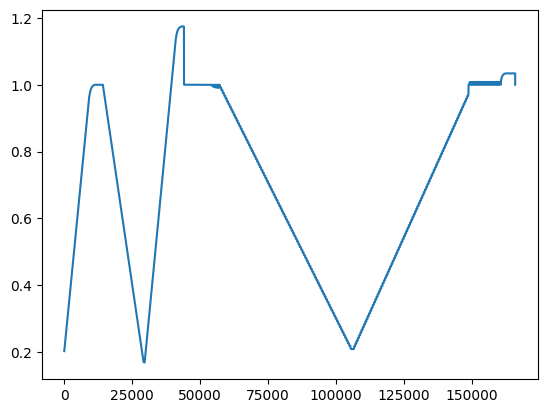

In [8]:
fig, ax = plt.subplots()
ax.plot(Result["Test_Time[s]"], Result["SOC"])